# Semana 07 — Visualização e Pipelines

**Curso:** Análise de Dados com Python — SENAI (Turma T5)
**UC (MSEP):** Manipulação de Dados com Python e SQL (150h) — Bloco 4, Semana 07 (fecha os 105h documentados do módulo)

Esta semana continua com o Restaurante Sabor Caseiro: o `dre_consolidado.csv` que você mesmo gerou no fechamento da Semana 06 — já limpo, sem duplicata nem outlier — é exatamente o tipo de arquivo que um time de BI recebe pronto pra virar gráfico. Você vai aprender a comunicar esses números com Matplotlib, organizar seu código em funções e classes, e fechar com um pipeline ETL completo, integrando Python com SQL.

> Em cada tópico abaixo: **exemplos resolvidos** + **1 atividade prática** para você fazer sozinho(a).

### 🧭 De onde você vem: fechando a Semana 06

Antes de entrar na Semana 07, vale reforçar de onde você está vindo e pra onde está indo dentro do curso.

**O que você viu e estudou na Semana 06:** o DRE do Restaurante Sabor Caseiro, com 2 filiais (Centro e Zona Sul), 50 linhas, 9 valores ausentes, linhas duplicadas e um erro de digitação em cada filial. Você aprendeu a detectar valor ausente com **`isna()`** (marca cada célula como `True`/`False` conforme está vazia ou não), tratar com **`dropna()`** (remove a linha) ou **`fillna()`** (preenche com um valor, geralmente a média), detectar duplicidade com **`duplicated()`** e outlier com a técnica do **IQR** (intervalo interquartil), normalizar colunas numa escala de 0 a 1, limpar texto sujo com **`.str.strip()`**/**`.str.replace()`**, e combinar as duas filiais com **`pd.concat()`**.

**O que você fez:** no final da semana, você montou um pipeline completo (as etapas de limpeza, uma atrás da outra) e exportou o resultado com **`to_csv()`** — gerando o `dre_consolidado.csv`, o arquivo que esta semana usa desde a primeira célula.

**Qual era o objetivo:** te dar as ferramentas pra pegar um dado real sujo e devolver um dado real confiável — pronto pra virar gráfico, relatório ou entrar num banco de dados.

**Onde você está agora:** encerrando o Bloco 4 desta UC ("Visualização e Pipelines — você comunica insights e entrega um projeto completo"). A Semana 06 resolveu a parte de **limpar**; a Semana 07, que começa agora, fecha o módulo resolvendo a parte de **comunicar** — transformando esse mesmo `dre_consolidado.csv` em gráfico, e organizando o código que faz isso num pipeline de verdade.

---
### 🔄 Retomada — o que vimos na Semana 06

Você já sabe detectar e tratar valor ausente, duplicidade e outlier, normalizar colunas, limpar texto sujo e combinar DataFrames com `pd.concat()` — e já tem, como resultado de tudo isso, o `dre_consolidado.csv` pronto. Esta semana usa esse mesmo arquivo do início ao fim: primeiro pra criar gráficos, depois pra organizar o código que gera esses gráficos, e por fim pra montar um pipeline completo que termina reintegrando esse dado a um banco de dados.

---
### 🟢 Abertura — Semana 07: Visualização e Pipelines

Última semana do Módulo Básico! <strong>Você vai aprender a comunicar insights com gráficos</strong>, usando o DRE já limpo do Restaurante Sabor Caseiro, e montar um pipeline de dados de ponta a ponta.

**O que você vai aprender nesta semana:**
- Criar gráficos com Matplotlib: linhas, barras e dispersão, com customização e exportação
- Organizar código em funções reutilizáveis e introdução a classes
- Montar um pipeline ETL completo e integrar Python com SQL

### 📌 Antes de começar: o dataset desta semana

Esta semana usa o mesmo `dre_consolidado.csv` que você gerou no fechamento da Semana 06 — o DRE das 2 filiais do Restaurante Sabor Caseiro (Centro e Zona Sul), já limpo: sem valor ausente, sem duplicata, sem outlier. São **46 linhas**, com 4 colunas: `categoria` (ex.: `Receita de Vendas`, `CMV`, `Despesas com Pessoal`), `tipo` (`Receita` ou `Despesa`), `mes` (`Jan` a `Abr`) e `valor`.

- `dataset/dre_consolidado.csv` — 46 linhas, já limpo (saída da Semana 06)

**Rodando no Google Colab?** Diferente do VS Code local, o Colab não enxerga os arquivos desta pasta automaticamente — rode a célula abaixo pra enviar o arquivo; ela já coloca tudo na subpasta `dataset/` certinha. Os datasets dos squads (seção 5) só precisam ser enviados na sexta-feira, quando cada squad for trabalhar com o seu.

In [1]:
# Se estiver rodando no Google Colab, esta célula abre a janela de upload
# e organiza o arquivo na subpasta dataset/, igual à estrutura do repositório.
# Selecione o arquivo desta semana: dre_consolidado.csv

import os

try:
    from google.colab import files
    enviados = files.upload()
    os.makedirs("dataset", exist_ok=True)
    for nome in enviados:
        os.replace(nome, f"dataset/{nome}")
except ImportError:
    print("Rodando localmente (VS Code) — o arquivo já está em dataset/, na pasta desta semana.")

Rodando localmente (VS Code) — o arquivo já está em dataset/, na pasta desta semana.


💡 **Lembrando da Semana 04:** `os` é o módulo de sistema operacional do Python — já vem pronto, sem precisar instalar. `os.makedirs("dataset", exist_ok=True)` cria a subpasta `dataset/` (sem erro caso ela já exista); `os.replace(nome, f"dataset/{nome}")`, dentro do `for`, move o arquivo enviado da raiz da sessão pra dentro dessa subpasta.

## 1. Matplotlib: Gráficos Básicos

Todo gráfico em Matplotlib começa com a mesma receita: `fig, ax = plt.subplots()`, depois `ax.plot(...)`/`ax.bar(...)`/`ax.scatter(...)`, e por fim `plt.show()`. `fig` é a **figura inteira** (a "folha", que você exporta/salva); `ax` são os **eixos** — a área de desenho dentro da figura, onde o gráfico realmente aparece. No dia a dia, você desenha em cima do `ax`, e só usa o `fig` quando precisa mexer na figura inteira (como exportar, Seção 2).

> 💡 Por que `fig, ax` desde o início? Existe um jeito mais curto (`plt.plot(...)` direto), mas só funciona bem para 1 gráfico isolado. O padrão `fig, ax` é o que você vai usar sempre — inclusive com vários gráficos juntos (Seção 2).

**Qual gráfico usar quando:**

| Tipo de gráfico | Quando usar |
|---|---|
| Linha (`ax.plot`) | Evolução ao longo do tempo |
| Barra (`ax.bar`) | Comparar categorias |
| Dispersão (`ax.scatter`) | Relação entre 2 variáveis numéricas |

### 🔹 Exemplo 1 — Gráfico de linha: receita mensal

📖 **Antes do código:** vamos usar o `dre_consolidado.csv` que você já conhece da Semana 06. Para ver a receita mês a mês, filtramos as linhas onde `tipo == "Receita"` e agrupamos por `mes` somando `valor` com `groupby("mes")["valor"].sum()` — `groupby()` agrupa linhas que têm o mesmo valor numa coluna (aqui, o mês) e permite aplicar uma conta (soma) dentro de cada grupo, a mesma ideia que você já usou na Semana 05. Como os nomes dos meses não ficam em ordem cronológica sozinhos (o Pandas ordena em ordem alfabética), pedimos a ordem certa selecionando com uma lista: `receita_mensal[["Jan", "Fev", "Mar", "Abr"]]`.

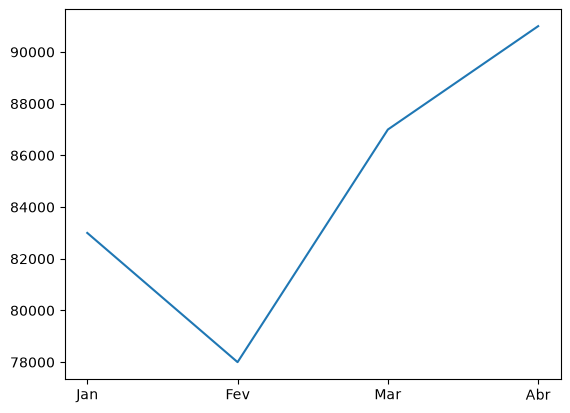

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

dre = pd.read_csv("dataset/dre_consolidado.csv")

ordem_meses = ["Jan", "Fev", "Mar", "Abr"]
receita_mensal = dre[dre["tipo"] == "Receita"].groupby("mes")["valor"].sum()
receita_mensal = receita_mensal[ordem_meses]

fig, ax = plt.subplots()
ax.plot(receita_mensal.index, receita_mensal.values)
plt.show()


### 🔹 Exemplo 2 — Gráfico de barras: despesa por categoria

📖 **Antes do código:** agora agrupamos por `categoria` em vez de `mes`, filtrando só as linhas de despesa (`tipo == "Despesa"`) — o mesmo `groupby()` do Exemplo 1, só que somando dentro de cada categoria de despesa (`CMV`, `Despesas com Pessoal`, etc.), não de cada mês. Como esses nomes de categoria são compridos, `ax.tick_params(axis="x", labelrotation=30)` inclina os rótulos do eixo X em 30 graus, pra eles não ficarem espremidos e ilegíveis embaixo do gráfico.

categoria
CMV                         88969.285714
Despesas Administrativas    30569.285714
Despesas Financeiras        17169.285714
Despesas com Pessoal        62639.285714
Impostos sobre Vendas       37569.285714
Name: valor, dtype: float64

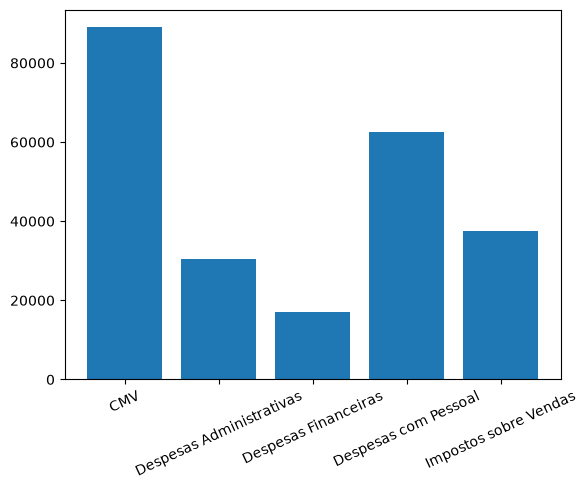

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

dre = pd.read_csv("dataset/dre_consolidado.csv")
despesa_por_categoria = dre[dre["tipo"] == "Despesa"].groupby("categoria")["valor"].sum()
display(despesa_por_categoria)

fig, ax = plt.subplots()
ax.bar(despesa_por_categoria.index, despesa_por_categoria.values)
ax.tick_params(axis="x", labelrotation=25)
plt.show()


### 🔹 Exemplo 3 — Gráfico de dispersão: receita x despesa por mês

📖 **Antes do código:** aqui calculamos DUAS séries mensais — receita e despesa — e colocamos uma no eixo X e outra no eixo Y. Cada ponto do gráfico é um mês: isso mostra se, quando a receita sobe, a despesa também sobe junto (relação entre 2 variáveis numéricas, como diz a tabela acima).

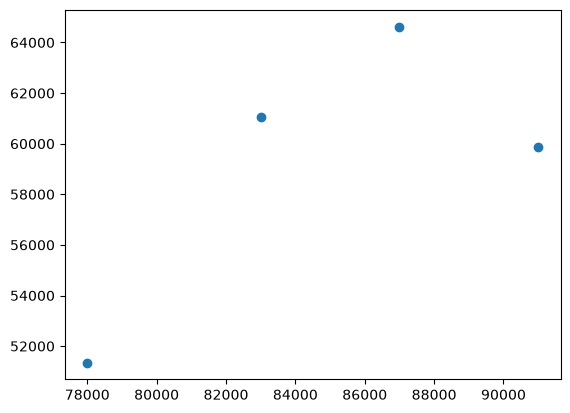

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

dre = pd.read_csv("dataset/dre_consolidado.csv")

ordem_meses = ["Jan", "Fev", "Mar", "Abr"]
receita_mensal = dre[dre["tipo"] == "Receita"].groupby("mes")["valor"].sum()[ordem_meses]
despesa_mensal = dre[dre["tipo"] == "Despesa"].groupby("mes")["valor"].sum()[ordem_meses]

fig, ax = plt.subplots()
ax.scatter(receita_mensal.values, despesa_mensal.values)  # x = receita do mês, y = despesa do mês
plt.show()

💡 **Esqueceu de exibir o gráfico no Colab?** Se nada aparecer, confira se a célula termina com `plt.show()`.

### ✏️ Atividade Prática 1 — Sua vez de programar

**Contextualização:** a diretoria do Restaurante Sabor Caseiro quer visualizar, num único olhar, qual categoria de despesa pesa mais no orçamento — pra decidir com qual fornecedor negociar primeiro.

**Comando:** usando o mesmo `dre_consolidado.csv`, crie um gráfico de barras mostrando o valor total de cada categoria de despesa, ordenado da maior para a menor (use `.sort_values(ascending=False)` no resultado do `groupby()`, como você já fez na Semana 05).

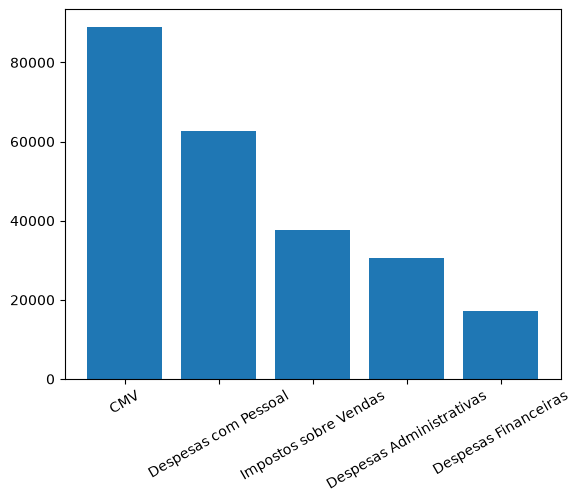

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

dre = pd.read_csv("dataset/dre_consolidado.csv")
despesa_por_categoria = dre[dre["tipo"] == "Despesa"].groupby("categoria")["valor"].sum().sort_values(ascending=False)

fig, ax = plt.subplots()
ax.bar(despesa_por_categoria.index, despesa_por_categoria.values)
ax.tick_params(axis="x", labelrotation=30)
plt.show()

---
## 2. Customização, Subplots e Exportação

### 🔹 Exemplo 1 — Customizando um gráfico

📖 **Antes do código:** `color` aceita um código hexadecimal (`#RRGGBB` — 2 dígitos para vermelho, 2 para verde, 2 para azul, de `00` a `ff`; `#CC0000` é um vermelho forte) ou nomes simples como `"red"`/`"blue"`. `marker` desenha um símbolo em cada ponto do gráfico — `"o"` é um círculo; outras opções comuns são `"s"` (quadrado) e `"^"` (triângulo). Nenhum dos dois é obrigatório — sem eles, o Matplotlib usa cor e estilo padrão.

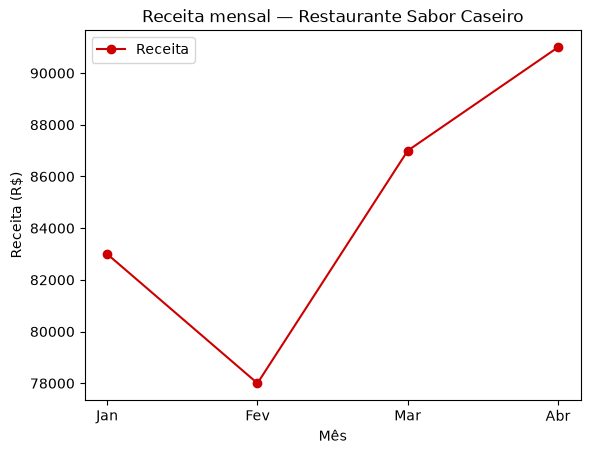

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

dre = pd.read_csv("dataset/dre_consolidado.csv")

ordem_meses = ["Jan", "Fev", "Mar", "Abr"]
receita_mensal = dre[dre["tipo"] == "Receita"].groupby("mes")["valor"].sum()[ordem_meses]

fig, ax = plt.subplots() #templates
ax.plot(receita_mensal.index, receita_mensal.values, color="#CC0000", marker="o", label="Receita")

ax.set_title("Receita mensal — Restaurante Sabor Caseiro")
ax.set_xlabel("Mês")
ax.set_ylabel("Receita (R$)")
ax.legend()
plt.show()

### 🔹 Exemplo 2 — Subplots: vários gráficos lado a lado

📖 **Antes do código:** até aqui, `plt.subplots()` sempre devolveu 1 `ax` só (Seção 1). Quando você pede mais de 1 gráfico — `plt.subplots(1, 2)`, por exemplo — ele devolve uma **lista de eixos**, guardada em `axs` (com "s", de plural). Por isso você acessa cada gráfico individual com `axs[0]`, `axs[1]`, etc. — a mesma ideia de indexar uma lista que você já usa desde a Semana 02.

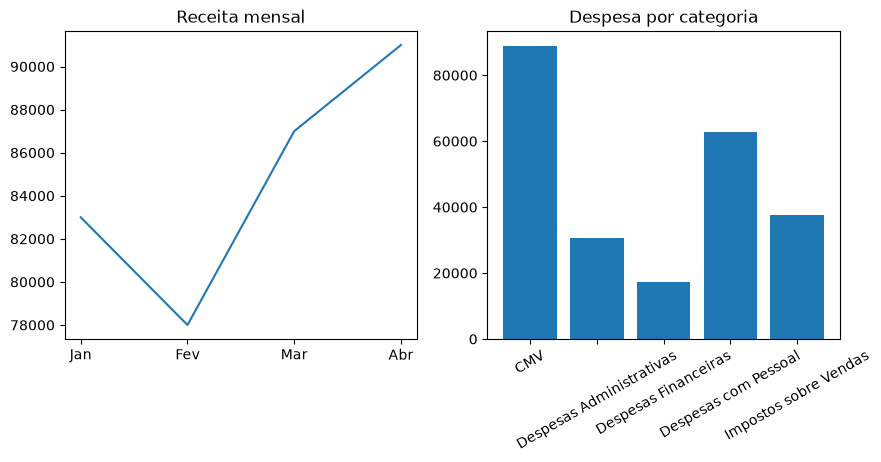

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

dre = pd.read_csv("dataset/dre_consolidado.csv")

ordem_meses = ["Jan", "Fev", "Mar", "Abr"]
receita_mensal = dre[dre["tipo"] == "Receita"].groupby("mes")["valor"].sum()[ordem_meses]
despesa_por_categoria = dre[dre["tipo"] == "Despesa"].groupby("categoria")["valor"].sum()

fig, axs = plt.subplots(1, 2, figsize=(10, 4))  # 1 linha, 2 colunas de gráficos

axs[0].plot(receita_mensal.index, receita_mensal.values)
axs[0].set_title("Receita mensal")

axs[1].bar(despesa_por_categoria.index, despesa_por_categoria.values)
axs[1].set_title("Despesa por categoria")
axs[1].tick_params(axis="x", labelrotation=30)

plt.show()

### Exportação de gráficos

`fig.savefig()` salva a figura inteira (não a tela) em um arquivo de imagem — essencial para colocar o gráfico num relatório ou apresentação.

Gráfico exportado.


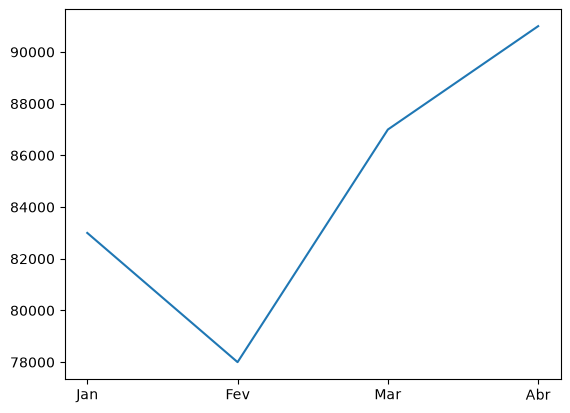

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

dre = pd.read_csv("dataset/dre_consolidado.csv")

ordem_meses = ["Jan", "Fev", "Mar", "Abr"]
receita_mensal = dre[dre["tipo"] == "Receita"].groupby("mes")["valor"].sum()[ordem_meses]

fig, ax = plt.subplots()
ax.plot(receita_mensal.index, receita_mensal.values)
fig.savefig("receita_mensal.png", dpi=150)
print("Gráfico exportado.")

### ✏️ Atividade Prática 2 — Sua vez de programar

**Contextualização:** o contador quer levar pra reunião mensal uma figura só, já pronta pra apresentar, comparando receita e despesa lado a lado — com título, rótulos e exportada como imagem.

**Comando:** usando o `dre_consolidado.csv`, crie uma figura com 2 subplots (receita mensal e despesa mensal, ambos por mês), customize cada um com título e rótulos de eixo, e exporte a figura com `savefig()`.

Gráfico exportado.


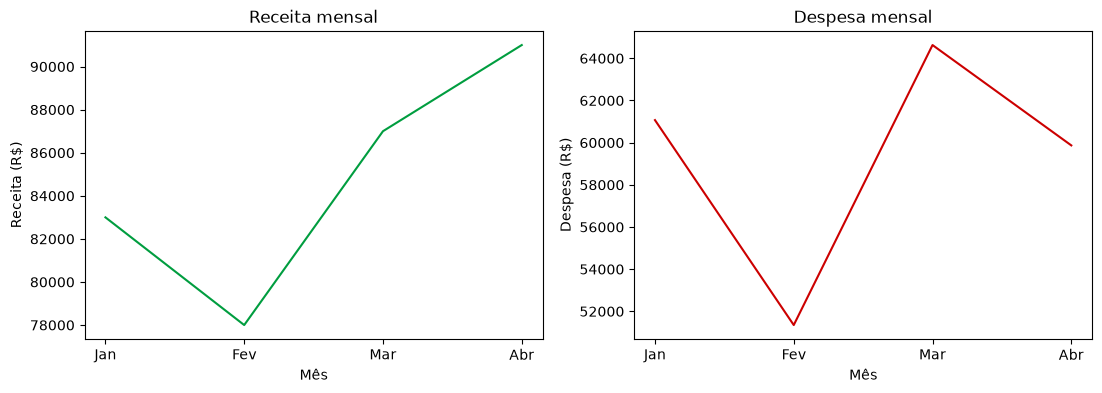

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

dre = pd.read_csv("dataset/dre_consolidado.csv")

ordem_meses = ["Jan", "Fev", "Mar", "Abr"]
receita_mensal = dre[dre["tipo"] == "Receita"].groupby("mes")["valor"].sum()[ordem_meses]
despesa_mensal = dre[dre["tipo"] == "Despesa"].groupby("mes")["valor"].sum()[ordem_meses]

fig, axs = plt.subplots(1, 2, figsize=(13, 4))

axs[0].plot(receita_mensal.index, receita_mensal.values, color="#009D3F")
axs[0].set_title("Receita mensal")
axs[0].set_xlabel("Mês")
axs[0].set_ylabel("Receita (R$)")

axs[1].plot(despesa_mensal.index, despesa_mensal.values, color="#CC0000")
axs[1].set_title("Despesa mensal")
axs[1].set_xlabel("Mês")
axs[1].set_ylabel("Despesa (R$)")

fig.savefig("receita_despesa_mensal.png", dpi=150)
print("Gráfico exportado.")

---
## 3. Funções Reutilizáveis e Introdução a Classes

Você já cria funções desde a Semana 04. Mas há situações em que uma função não basta: quando você precisa agrupar **dados** e **comportamento** juntos.

### 🔹 Exemplo 1 — Função de transformação reutilizável: normalizando a despesa por categoria

📖 **Antes do código:** a função abaixo aplica a fórmula de **normalização min-max** — ela pega cada valor de uma coluna e recalcula numa escala de 0 a 1, usando `(valor - mínimo) / (máximo - mínimo)`. O menor valor da coluna vira 0, o maior vira 1, e os demais ficam proporcionalmente entre os dois. Vamos aplicar isso na despesa por categoria: assim dá pra comparar `CMV` (o maior valor em reais) com `Despesas Financeiras` (o menor) numa escala comum, sem o tamanho em reais distorcer a comparação.

In [10]:
import pandas as pd

dre = pd.read_csv("dataset/dre_consolidado.csv")
despesa_por_categoria = dre[dre["tipo"] == "Despesa"].groupby("categoria")["valor"].sum()

def normalizar(coluna):
    return (coluna - coluna.min()) / (coluna.max() - coluna.min())

despesa_normalizada = normalizar(despesa_por_categoria)
print(despesa_normalizada)

categoria
CMV                         1.000000
Despesas Administrativas    0.186630
Despesas Financeiras        0.000000
Despesas com Pessoal        0.633287
Impostos sobre Vendas       0.284123
Name: valor, dtype: float64


### 🔹 Exemplo 2 — Sua primeira classe: participação de uma categoria no total

📖 **Antes do código:** uma **classe** é um molde — define o que todo objeto desse tipo vai ter (dados) e o que ele vai saber fazer (comportamento). Um **objeto** é uma "cópia preenchida" desse molde, com valores próprios. Vamos criar uma classe `Categoria`, que guarda o nome e o valor total de uma categoria de despesa, e sabe calcular sozinha qual porcentagem representa do total.

| Termo | O que é |
|---|---|
| `class Categoria:` | Define o "molde" — o que toda Categoria vai ter/fazer |
| `__init__` | Roda automaticamente ao criar uma Categoria nova, para preencher os dados iniciais |
| `self` | Representa "esta Categoria específica" — é assim que cada objeto guarda seus próprios dados |
| `cmv = Categoria(...)` | Cria um **objeto** — uma cópia preenchida do molde |
| **Método** | O nome que se dá para uma função definida dentro de uma classe (ex.: `participacao`) |

In [11]:
import pandas as pd

dre = pd.read_csv("dataset/dre_consolidado.csv")
despesa_por_categoria = dre[dre["tipo"] == "Despesa"].groupby("categoria")["valor"].sum()

class Categoria:
    def __init__(self, nome, valor_total):
        self.nome = nome
        self.valor_total = valor_total

    def participacao(self, lais):
        return self.valor_total / lais * 100

cmv = Categoria("CMV", despesa_por_categoria["CMV"])
print(cmv.nome, round(cmv.participacao(despesa_por_categoria.sum()), 1))

CMV 37.6


💡 **Função x Classe:** uma função recebe dados, processa, devolve um resultado, e esquece tudo depois. Uma classe **guarda** dados (no `self`) e empacota junto as ações que fazem sentido para aqueles dados.

> ⚠️ **Veja como é um erro real do Python.** Se você esquecer o `self` ao definir um método, ao chamar `Categoria("Impostos sobre Vendas", 37569.29).mostrar()` você vai ver `TypeError: Categoria.mostrar() takes 0 positional arguments but 1 was given`.

In [12]:
class CategoriaComBug:
    def mostrar():  # faltou o self
        print("categoria")

try:
    CategoriaComBug().mostrar()
except TypeError as e:
    print(f"Erro: {e}")

Erro: CategoriaComBug.mostrar() takes 0 positional arguments but 1 was given


### ✏️ Atividade Prática 3 — Sua vez de programar

**Contextualização:** a diretoria também quer saber, mês a mês, qual fatia da receita total do quadrimestre (Jan-Abr) cada mês representa — pra identificar se existe sazonalidade nas vendas.

**Comando:** crie uma classe `Mes` com `nome` e `receita`, e um método `participacao(total_periodo)` que devolve a porcentagem que a receita daquele mês representa do total do período. Teste com o mês de Abril.

In [13]:
import pandas as pd

dre = pd.read_csv("dataset/dre_consolidado.csv")
ordem_meses = ["Jan", "Fev", "Mar", "Abr"]
receita_mensal = dre[dre["tipo"] == "Receita"].groupby("mes")["valor"].sum()[ordem_meses]

class Mes:
    def __init__(self, nome, receita):
        self.nome = nome
        self.receita = receita

    def participacao(self, total_periodo):
        return self.receita / total_periodo * 100

abril = Mes("Abr", receita_mensal["Abr"])
print(abril.nome, round(abril.participacao(receita_mensal.sum()), 1))

Abr 26.8


---
## 4. ETL e Integração Python-SQL

**ETL** significa **E**xtract (extrair) → **T**ransform (transformar) → **L**oad (carregar). Você já faz isso desde a Semana 04 — só não tinha esse nome:

| Etapa | O que você já aprendeu que se encaixa aqui |
|---|---|
| **E**xtract | Ler um arquivo (`pd.read_csv`) — o `dre_consolidado.csv` |
| **T**ransform | Limpar e transformar com Pandas (Semana 06) — agora, normalizar |
| **L**oad | Salvar o resultado — em arquivo ou em banco de dados |

💡 **E as classes que você acabou de aprender?** Este pipeline é pequeno, então uma função dá conta do recado — é mais direto. Mas quando um pipeline cresce (várias fontes de dados, várias transformações, configuração para lembrar), empacotar tudo numa classe (como você fez com `Categoria`) ajuda a organizar — é a mesma ideia, só aplicada em maior escala. Guarde essa conexão para quando os pipelines ficarem mais complexos.

### 🔹 Exemplo 1 — Um pipeline ETL completo: despesa por categoria, normalizada

📖 **Antes do código:** depois de agrupar a despesa por categoria (Extract feito na leitura, Transform no `groupby`), o resultado do `groupby()` fica com `categoria` como índice, não como coluna comum — `.reset_index()` devolve `categoria` pra uma coluna normal, o que facilita adicionar a coluna `valor_normalizado` do lado.

In [14]:
import pandas as pd
import sqlite3

dre = pd.read_csv("dataset/dre_consolidado.csv")                                                     # E - Extract

despesa_por_categoria = dre[dre["tipo"] == "Despesa"].groupby("categoria")["valor"].sum().reset_index()

def normalizar(coluna):
    return (coluna - coluna.min()) / (coluna.max() - coluna.min())
despesa_por_categoria["valor_normalizado"] = normalizar(despesa_por_categoria["valor"])              # T - Transform

despesa_por_categoria.to_csv("despesa_por_categoria.csv", index=False)                               # L - Load (em arquivo)
print("Pipeline concluído.")


Pipeline concluído.


### 🔹 Exemplo 2 — Load num banco de dados com sqlite3

📖 **Antes do código:** depois de carregar os dados numa tabela, você pode consultá-los com **SQL** — a linguagem usada para conversar com bancos de dados. Neste exemplo, `SELECT * FROM despesas WHERE valor > 30000` lê quase como uma frase: "selecione tudo (`*`) da tabela `despesas` onde o valor é maior que 30000" — as categorias de maior peso no orçamento. Você vai aprender SQL de verdade, a fundo, no Bloco 5 do curso (Semanas 09-10) — aqui é só uma prévia de como Python e SQL conversam.

In [15]:
import pandas as pd
import sqlite3

dre = pd.read_csv("dataset/dre_consolidado.csv")
despesa_por_categoria = dre[dre["tipo"] == "Despesa"].groupby("categoria")["valor"].sum().reset_index()  # repetindo o Extract+Transform do Exemplo 1

def normalizar(coluna):
    return (coluna - coluna.min()) / (coluna.max() - coluna.min())

despesa_por_categoria["valor_normalizado"] = normalizar(despesa_por_categoria["valor"])

conexao = sqlite3.connect("dados.db")
despesa_por_categoria.to_sql("despesas", conexao, index=False, if_exists="replace")  # L - Load (em banco)

resultado = pd.read_sql("SELECT * FROM despesas WHERE valor > 30000", conexao)
print(resultado)

conexao.close()

                  categoria         valor  valor_normalizado
0                       CMV  88969.285714           1.000000
1  Despesas Administrativas  30569.285714           0.186630
2      Despesas com Pessoal  62639.285714           0.633287
3     Impostos sobre Vendas  37569.285714           0.284123


💡 **Por que `sqlite3` e não PostgreSQL aqui?** `sqlite3` não precisa de servidor nem configuração. No mercado, o mesmo `pandas.to_sql()`/`pd.read_sql()` funciona com PostgreSQL (via `SQLAlchemy`), só muda a conexão.

### ✏️ Atividade Prática 4 — Sua vez de programar

**Contextualização:** o time de BI quer receber, num banco de dados, a receita mensal já calculada — pra plugar direto num painel, sem reprocessar nada.

**Comando:** monte um pipeline ETL com o `dre_consolidado.csv`: extraia a receita mensal (`groupby` por mês), transforme aplicando a normalização, e carregue o resultado numa tabela SQLite chamada `receitas`.

In [16]:
import pandas as pd
import sqlite3

dre = pd.read_csv("dataset/dre_consolidado.csv")                                                          # E

ordem_meses = ["Jan", "Fev", "Mar", "Abr"]
receita_mensal = dre[dre["tipo"] == "Receita"].groupby("mes")["valor"].sum()[ordem_meses].reset_index()
def normalizar(coluna):
    return (coluna - coluna.min()) / (coluna.max() - coluna.min())

receita_mensal["valor_normalizado"] = normalizar(receita_mensal["valor"])                                 # T

minha_conexao = sqlite3.connect("meu_banco.db")
receita_mensal.to_sql("receitas", minha_conexao, index=False, if_exists="replace")                        # L
print(pd.read_sql("SELECT * FROM receitas", minha_conexao))
minha_conexao.close()

   mes    valor  valor_normalizado
0  Jan  83000.0           0.384615
1  Fev  78000.0           0.000000
2  Mar  87000.0           0.692308
3  Abr  91000.0           1.000000


---
### 🏁 Fechamento — Módulo Básico Completo

**Nesta semana você aprendeu:**
- Gráficos profissionais com Matplotlib: tipos, customização e exportação
- Funções reutilizáveis e introdução a classes para organizar pipelines
- Pipeline ETL completo: coletar → limpar → analisar → visualizar → comunicar

**Próxima semana:** <strong>Parabéns — você concluiu o Módulo Básico de Análise de Dados com Python!</strong> Prepare-se para o Módulo Específico: Gestão de Dados com Arquitetura Moderna.

---
## 5. Treino em Squads e o Mini Projeto — Sexta-feira (Encontro 3)

Esta seção é usada **em sala (ou em salas remotas/breakout)** na sexta-feira. Cada squad recebe um dataset diferente e precisa criar **pelo menos 2 tipos de gráfico diferentes** + **1 insight**.

### Squad B — Vendas mensais de uma loja

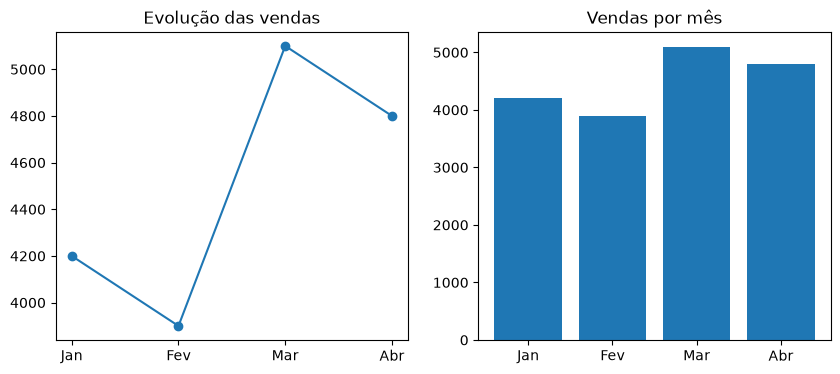

In [17]:
# ✅ Gabarito:
import pandas as pd
import matplotlib.pyplot as plt

dataset_squad_b = pd.DataFrame({
    "mes": ["Jan", "Fev", "Mar", "Abr"],
    "receita": [4200, 3900, 5100, 4800],
})

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(dataset_squad_b["mes"], dataset_squad_b["receita"], marker="o")
axs[0].set_title("Evolução das vendas")
axs[1].bar(dataset_squad_b["mes"], dataset_squad_b["receita"])
axs[1].set_title("Vendas por mês")
plt.show()

✅ **Gabarito Squad B:** linha (evolução) + barra (comparação mensal) — os dois tipos mais diretos pra um dataset com mês e valor. **Insight:** Março foi o melhor mês (R$ 5.100), Fevereiro o mais fraco (R$ 3.900) — uma queda antes de recuperar em Abril.

### Squad C — Avaliações de apps por categoria

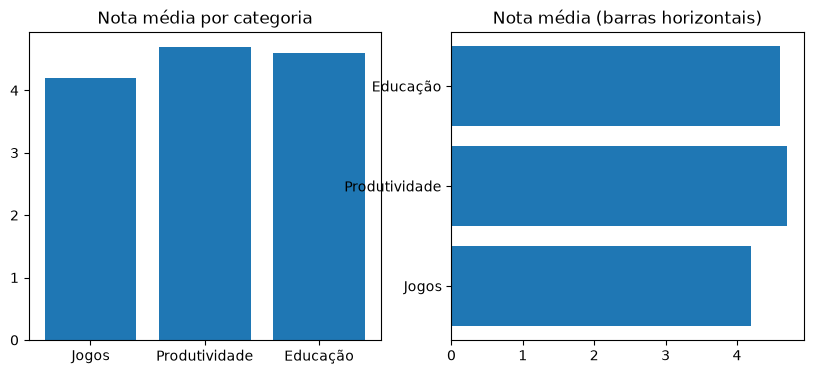

In [18]:
# ✅ Gabarito:
import pandas as pd
import matplotlib.pyplot as plt

dataset_squad_c = pd.DataFrame({
    "categoria_app": ["Jogos", "Produtividade", "Educação"],
    "nota_media": [4.2, 4.7, 4.6],
})

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].bar(dataset_squad_c["categoria_app"], dataset_squad_c["nota_media"])
axs[0].set_title("Nota média por categoria")
axs[1].barh(dataset_squad_c["categoria_app"], dataset_squad_c["nota_media"])
axs[1].set_title("Nota média (barras horizontais)")
plt.show()

✅ **Gabarito Squad C:** `ax.bar()` e `ax.barh()` (barra horizontal) — mesma ideia de comparar categorias, em duas orientações diferentes. Se você tentar dispersão aqui, repare que só existe 1 coluna numérica (`nota_media`) — dispersão exige 2. **Insight:** Produtividade tem a maior nota média (4,7), Jogos a menor (4,2).

### Squad D — Tempo de espera x satisfação de clientes

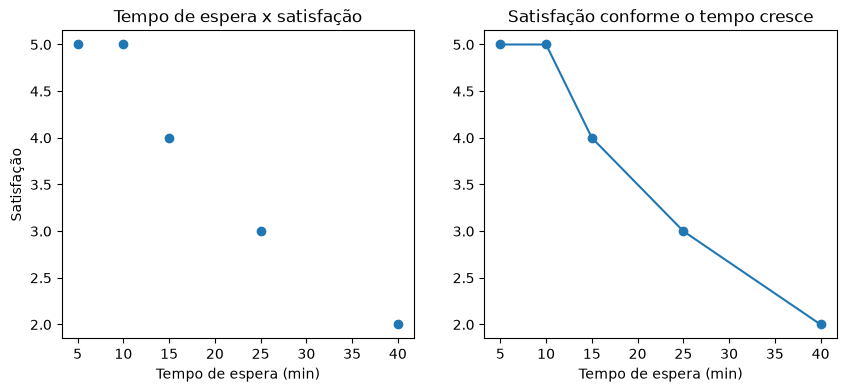

In [19]:
# ✅ Gabarito:
import pandas as pd
import matplotlib.pyplot as plt

dataset_squad_d = pd.DataFrame({
    "tempo_espera_min": [10, 25, 15, 40, 5],
    "satisfacao": [5, 3, 4, 2, 5],
})

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].scatter(dataset_squad_d["tempo_espera_min"], dataset_squad_d["satisfacao"])
axs[0].set_title("Tempo de espera x satisfação")
axs[0].set_xlabel("Tempo de espera (min)")
axs[0].set_ylabel("Satisfação")

ordenado = dataset_squad_d.sort_values("tempo_espera_min")
axs[1].plot(ordenado["tempo_espera_min"], ordenado["satisfacao"], marker="o")
axs[1].set_title("Satisfação conforme o tempo cresce")
axs[1].set_xlabel("Tempo de espera (min)")
plt.show()

✅ **Gabarito Squad D:** este é o único dataset com 2 colunas numéricas de verdade, então dispersão é a escolha natural — o segundo gráfico usa `.sort_values("tempo_espera_min")` pra desenhar uma linha coerente da esquerda pra direita. **Insight:** relação claramente inversa — os clientes que esperaram menos de 10 minutos deram nota 5, o que esperou 40 minutos deu nota 2.

### Squad E — Vendas por região

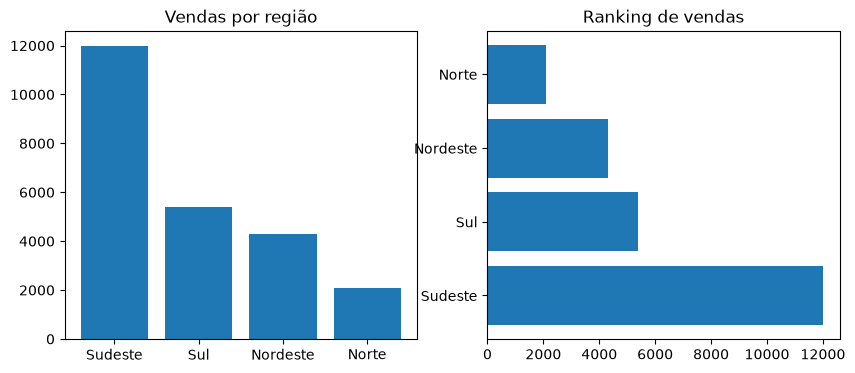

In [20]:
# ✅ Gabarito:
import pandas as pd
import matplotlib.pyplot as plt

dataset_squad_e = pd.DataFrame({
    "regiao": ["Sudeste", "Sul", "Nordeste", "Norte"],
    "vendas": [12000, 5400, 4300, 2100],
})

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].bar(dataset_squad_e["regiao"], dataset_squad_e["vendas"])
axs[0].set_title("Vendas por região")

ordenado = dataset_squad_e.sort_values("vendas", ascending=False)
axs[1].barh(ordenado["regiao"], ordenado["vendas"])
axs[1].set_title("Ranking de vendas")
plt.show()

✅ **Gabarito Squad E:** barra simples + barra horizontal ordenada (reaproveitando `.sort_values()`, já visto na Atividade Prática 1). **Insight:** o Sudeste concentra mais que o dobro das vendas da segunda região (Sul) — sozinho, vende mais que Nordeste e Norte somados.

### 🗣️ Debate coletivo (após as apresentações)

Depois que todos os squads apresentarem, discuta com a turma:

- Por que vocês escolheram esses tipos de gráfico para esse dataset?
- Algum squad usou customização (cores, títulos, legendas) para deixar o insight mais claro?
- O que mudaria se vocês tivessem que apresentar esse gráfico para alguém de fora da área de dados?

### 📌 Mini Projeto (Situação de Aprendizagem Integradora)

Depois do treino, o professor apresenta o **Mini Projeto** — escolha um dataset público real (IBGE, Dados Abertos, Kaggle ou Portal Brasileiro de Dados Abertos) e aplique, em squad, tudo o que você aprendeu nos Blocos 1–4: importar → limpar → transformar → visualizar → comunicar insights.

Detalhes completos, rubrica de 100 pts (4 critérios) e instruções de entrega em `05_atividade_avaliativa.md`.

---
### Assinatura

Curso: **Análise de Dados com Python — SENAI (Turma T5)**
Semana 07 — Visualização e Pipelines

*Prof. Especialista Cláudio F. Neves*